# 04 · Визуальные представления, CLIP и текст → рамка → маска

Практикум к лекции 5. **Два занятия по 90 минут**, затем оформление отчёта (около 60–90 минут).
Различайте: (1) учебные численные матрицы, (2) реальный инференс замороженных моделей,
(3) истинную разметку данных. Ни один учебный массив ниже не обозначен как результат CLIP.

Для каждого стенда заполните четыре строки: **прогноз → изменённый параметр → наблюдение с числом → объяснение**.
Сначала меняйте один параметр. Ошибочный прогноз полезен, если указан механизм ошибки.
Исходный опыт каждого стенда выполняется один раз при открытии. Повторный дорогой CLIP/DINO/SAM запускается кнопкой.
DINO сохраняет logits для повторных порогов, а SAM повторно использует признаки того же изображения при смене рамки.

Ноутбук самодостаточен: весь код, небольшие метаданные и тесты встроены. Фотографии и веса скачиваются
в пользовательский кэш с SHA-256 и не должны входить в сдаваемый архив. Первый запуск: примерно 1.6 GiB весов + 54 MB Penn–Fudan;
нужно около 4 GB свободного места и 6–8 GB RAM.
Для CLIP, Grounding DINO и SAM автоматически выбирается CUDA, когда она доступна PyTorch; иначе CPU.
Выбранное устройство выводится в ячейке помощников. Учебные стенды с NumPy остаются на CPU.
Если видеокарта есть, а вывод показывает CPU, проверьте `torch.cuda.is_available()` и установку PyTorch с поддержкой CUDA.
Для ручного выбора задайте `VISUAL_LAB_DEVICE=cpu` или `VISUAL_LAB_DEVICE=cuda` до запуска ячейки помощников.
Оценки времени — ориентир; фактические измерения появятся в выводе. В тестах версии фиксированы в README.

## Подготовка
При первом запуске раскомментируйте строку `%pip` в следующей ячейке, выполните её и перезапустите ядро. Затем выполняйте ноутбук сверху вниз. Если зависимости уже установлены по requirements.txt, повторная установка не нужна. Не включайте кэш, фотографии и веса в сдачу.

In [ ]:
# Требуется интернет только для первого запуска. Установку выполните один раз в новом ядре.
%pip install -q torch==2.5.1 torchvision==0.20.1 numpy==2.4.6 matplotlib==3.11.0 pillow==12.3.0 ipywidgets==8.1.9 transformers==4.51.3 tokenizers==0.21.1 huggingface-hub==0.30.2 safetensors==0.5.3
# После изменения пакетов перезапустите ядро и выполните ноутбук сверху вниз.
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass
import torch
if not torch.cuda.is_available(): torch.set_num_threads(min(4,torch.get_num_threads()))

In [ ]:
DATA_MANIFEST = [{'id': 'astronaut', 'filename': 'astronaut.png', 'sha256': '88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png', 'credit': 'NASA, public domain'}, {'id': 'camera', 'filename': 'camera.png', 'sha256': 'b0793d2adda0fa6ae899c03989482bff9a42d3d5690fc7e3648f2795d730c23a', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/camera.png', 'credit': 'Lav Varshney, CC0'}, {'id': 'coffee', 'filename': 'coffee.png', 'sha256': 'cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coffee.png', 'credit': 'Rachel Michetti, CC0'}, {'id': 'chelsea', 'filename': 'chelsea.png', 'sha256': '596aa1e7cb875eb79f437e310381d26b338a81c2da23439704a73c4651e8c4bb', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/chelsea.png', 'credit': 'Stefan van der Walt, CC0'}, {'id': 'rocket', 'filename': 'rocket.jpg', 'sha256': 'c2dd0de7c538df8d111e479619b129464d0269d0ae5fd18ca91d33a7fdfea95c', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/rocket.jpg', 'credit': 'SpaceX, public domain'}, {'id': 'coins', 'filename': 'coins.png', 'sha256': 'f8d773fc9cfa6f4d8e5942dc34d0a0788fcaed2a4fefbbed0aef5398d7ef4cba', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coins.png', 'credit': 'Brooklyn Museum, no known copyright restrictions'}, {'id': 'horse', 'filename': 'horse.png', 'sha256': 'c7fb60789fe394c485f842291ea3b21e50d140f39d6dcb5fb9917cc178225455', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/horse.png', 'credit': 'Andreas Preuss, CC0; illustration'}, {'id': 'hubble_deep_field', 'filename': 'hubble_deep_field.jpg', 'sha256': '3a19c5dd8a927a9334bb1229a6d63711b1c0c767fb27e2286e7c84a3e2c2f5f4', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/hubble_deep_field.jpg', 'credit': 'NASA, public domain'}]
MODEL_MANIFEST = {'clip': {'repo': 'openai/clip-vit-base-patch32', 'revision': '3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268', 'files': [{'name': 'config.json', 'url': 'https://huggingface.co/openai/clip-vit-base-patch32/resolve/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json', 'sha256': 'b575ef3c36f2a057fa19e221650105052d61cc9c1a972ec15019c6261ec98770', 'size': 4186}, {'name': 'merges.txt', 'url': 'https://huggingface.co/openai/clip-vit-base-patch32/resolve/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/merges.txt', 'sha256': 'f526393189112391ce6f9795d4695f704121ce452c3aad1f5335cc41337eba85', 'size': 524657}, {'name': 'preprocessor_config.json', 'url': 'https://huggingface.co/openai/clip-vit-base-patch32/resolve/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/preprocessor_config.json', 'sha256': '910e70b3956ac9879ebc90b22fb3bc8a75b6a0677814500101a4c072bd7857bd', 'size': 316}, {'name': 'tokenizer.json', 'url': 'https://huggingface.co/openai/clip-vit-base-patch32/resolve/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/tokenizer.json', 'sha256': 'b556ac8c99757ffb677208af34bc8c6721572114111a6e0aaf5fa69ff0b8d842', 'size': 2224041}, {'name': 'tokenizer_config.json', 'url': 'https://huggingface.co/openai/clip-vit-base-patch32/resolve/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/tokenizer_config.json', 'sha256': '34b7336e4bee12e0a9730eaf5189f582ef3c3eea5027f65730e5717256755aad', 'size': 592}, {'name': 'vocab.json', 'url': 'https://huggingface.co/openai/clip-vit-base-patch32/resolve/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/vocab.json', 'sha256': '5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363', 'size': 862328}, {'name': 'pytorch_model.bin', 'url': 'https://huggingface.co/openai/clip-vit-base-patch32/resolve/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/pytorch_model.bin', 'sha256': 'a63082132ba4f97a80bea76823f544493bffa8082296d62d71581a4feff1576f', 'size': 605247071}]}, 'dino': {'repo': 'IDEA-Research/grounding-dino-tiny', 'revision': 'a2bb814dd30d776dcf7e30523b00659f4f141c71', 'files': [{'name': 'added_tokens.json', 'url': 'https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/a2bb814dd30d776dcf7e30523b00659f4f141c71/added_tokens.json', 'sha256': '909e96cb32d92ce728a01bc99850cbba26196d74115c17ebeb019275412588f2', 'size': 82}, {'name': 'config.json', 'url': 'https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/a2bb814dd30d776dcf7e30523b00659f4f141c71/config.json', 'sha256': 'eec82c5ab66e16df12a9a212e68ac011779927c2536cf9078658e35d85f0c67a', 'size': 1644}, {'name': 'model.safetensors', 'url': 'https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/a2bb814dd30d776dcf7e30523b00659f4f141c71/model.safetensors', 'sha256': '1a2412ef99bd74bcd3c2a246fa1e48581f8889a1300c9051974741314fc042f3', 'size': 689359096}, {'name': 'preprocessor_config.json', 'url': 'https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/a2bb814dd30d776dcf7e30523b00659f4f141c71/preprocessor_config.json', 'sha256': '8454179ba95e2ad22947835aad7b45862a601fc0055ab88bf1ee70892d3aea60', 'size': 457}, {'name': 'tokenizer.json', 'url': 'https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/a2bb814dd30d776dcf7e30523b00659f4f141c71/tokenizer.json', 'sha256': 'd241a60d5e8f04cc1b2b3e9ef7a4921b27bf526d9f6050ab90f9267a1f9e5c66', 'size': 711396}, {'name': 'tokenizer_config.json', 'url': 'https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/a2bb814dd30d776dcf7e30523b00659f4f141c71/tokenizer_config.json', 'sha256': 'd40ab645b68211910b9170d22433d43186a6ec8ee6fd10ba170524b25bf4fb56', 'size': 1237}, {'name': 'vocab.txt', 'url': 'https://huggingface.co/IDEA-Research/grounding-dino-tiny/resolve/a2bb814dd30d776dcf7e30523b00659f4f141c71/vocab.txt', 'sha256': '07eced375cec144d27c900241f3e339478dec958f92fddbc551f295c992038a3', 'size': 231508}]}, 'sam': {'repo': 'facebook/sam-vit-base', 'revision': '70c1a07f894ebb5b307fd9eaaee97b9dfc16068f', 'files': [{'name': 'config.json', 'url': 'https://huggingface.co/facebook/sam-vit-base/resolve/70c1a07f894ebb5b307fd9eaaee97b9dfc16068f/config.json', 'sha256': '5ebd0d8643b486f3a716bf17c2a15531eb818b2b96ff0c6c5dcc88fa015161af', 'size': 6566}, {'name': 'model.safetensors', 'url': 'https://huggingface.co/facebook/sam-vit-base/resolve/70c1a07f894ebb5b307fd9eaaee97b9dfc16068f/model.safetensors', 'sha256': '892c410e496344e527255ccdcb2cb7244a609acb5389c7c4fdba1288f861c579', 'size': 374979480}, {'name': 'preprocessor_config.json', 'url': 'https://huggingface.co/facebook/sam-vit-base/resolve/70c1a07f894ebb5b307fd9eaaee97b9dfc16068f/preprocessor_config.json', 'sha256': '225545a743c654e3c495ec6f545a0eaba57c8ba3fbbd8483b3cb1c0fc58db517', 'size': 466}]}}
"""Public helpers; model inference is real, synthetic teaching data are labelled."""
from pathlib import Path
import os, json, hashlib, time, zipfile, urllib.request, urllib.error
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

CACHE = Path(os.environ.get('VISUAL_LAB_CACHE', str(Path.home()/'.cache'/'applied-ai-visual')))
CACHE.mkdir(parents=True, exist_ok=True)

def select_device():
    """Use a PyTorch-visible CUDA GPU by default, with an explicit CPU override."""
    import torch
    requested=os.environ.get('VISUAL_LAB_DEVICE','auto').strip().lower()
    if requested not in ('auto','cuda','cpu'):
        raise ValueError("VISUAL_LAB_DEVICE must be 'auto', 'cuda', or 'cpu'")
    if requested=='cuda' and not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable to PyTorch; check the driver and CUDA-enabled PyTorch installation")
    device='cuda' if requested=='cuda' or (requested=='auto' and torch.cuda.is_available()) else 'cpu'
    if device=='cuda':
        print('Устройство для CLIP, Grounding DINO и SAM: CUDA — '+torch.cuda.get_device_name(0))
    else:
        print('Устройство для CLIP, Grounding DINO и SAM: CPU. Для GPU проверьте torch.cuda.is_available().')
    return device

DEVICE = select_device()

# DATA_MANIFEST and MODEL_MANIFEST are embedded above this cell.
def sha256(path):
    digest=hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''): digest.update(chunk)
    return digest.hexdigest()

def fetch(url, path, expected):
    path=Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and sha256(path)==expected: return path
    part=path.with_suffix(path.suffix+'.part')
    print('Загружаю',path.name,'— размер и ход загрузки показаны ниже.',flush=True)
    try:
        with urllib.request.urlopen(url,timeout=30) as response, part.open('wb') as output:
            total=response.headers.get('Content-Length')
            total=int(total) if total and total.isdigit() else None
            received=0;last_report=time.monotonic();next_report=10*1024*1024
            while True:
                chunk=response.read(1024*1024)
                if not chunk: break
                output.write(chunk);received+=len(chunk)
                now=time.monotonic()
                if received>=next_report or now-last_report>=10:
                    progress=f'{received/2**20:.1f} MiB'
                    if total: progress+=f' из {total/2**20:.1f} MiB'
                    print(path.name+': '+progress,flush=True)
                    next_report=received+10*1024*1024;last_report=now
        if sha256(part)!=expected: raise ValueError('Неверная контрольная сумма SHA-256: '+path.name)
        part.replace(path)
        print(path.name+': загружен и проверен.',flush=True)
    except (urllib.error.URLError,TimeoutError) as exc:
        part.unlink(missing_ok=True)
        raise RuntimeError(f'Не удалось загрузить {path.name}: {exc}. Проверьте интернет и повторите запуск.') from exc
    except Exception:
        part.unlink(missing_ok=True)
        raise
    return path

def gallery():
    return [Image.open(fetch(r['url'],CACHE/'gallery'/r['filename'],r['sha256'])).convert('RGB') for r in DATA_MANIFEST]

class FrozenCLIP:
    def __init__(self,device=None):
        import torch
        from transformers import CLIPModel,CLIPProcessor
        self.torch=torch; self.device=DEVICE if device is None else device
        path=model_files('clip')
        self.processor=CLIPProcessor.from_pretrained(path,local_files_only=True)
        self.model=CLIPModel.from_pretrained(path,local_files_only=True).eval().to(self.device)
    def images(self, images):
        t=time.perf_counter()
        x=self.processor(images=images,return_tensors='pt').to(self.device)
        with self.torch.inference_mode(): y=self.model.get_image_features(**x)
        if self.device.startswith('cuda'): self.torch.cuda.synchronize()
        self.last_seconds=time.perf_counter()-t
        return y.cpu().numpy().astype(np.float64)
    def texts(self,texts):
        x=self.processor(text=texts,padding=True,truncation=True,return_tensors='pt').to(self.device)
        with self.torch.inference_mode(): y=self.model.get_text_features(**x)
        return y.cpu().numpy().astype(np.float64)

def model_files(name):
    spec=MODEL_MANIFEST[name]
    target=CACHE/'models'/name
    for item in spec['files']: fetch(item['url'],target/item['name'],item['sha256'])
    return target

def unit(x):
    x=np.asarray(x,dtype=float)
    if not np.isfinite(x).all(): raise ValueError('Non-finite vector')
    scale=np.max(np.abs(x),axis=-1,keepdims=True,initial=0)
    scaled=np.divide(x,scale,out=np.zeros_like(x),where=scale>0)
    length=np.sqrt(np.sum(scaled*scaled,axis=-1,keepdims=True))
    return np.divide(scaled,length,out=np.zeros_like(scaled),where=length>0)

def softmax(x):
    x=np.asarray(x,float); e=np.exp(x-np.max(x,axis=-1,keepdims=True))
    return e/e.sum(axis=-1,keepdims=True)

def show_gallery(images, scores=None, order=None, title=''):
    order=np.arange(len(images)) if order is None else np.asarray(order)
    fig, axes=plt.subplots(1,len(order),figsize=(2.1*len(order),2.7),squeeze=False)
    for ax,j in zip(axes.flat,order):
        ax.imshow(images[j]);ax.axis('off')
        ax.set_title(DATA_MANIFEST[j]['id']+(f'\ncos={scores[j]:.3f}' if scores is not None else ''),fontsize=9)
    fig.suptitle(title);plt.tight_layout();plt.show()
    return fig

PENN_SHA='9095a9613c95586f1c7f2a327d454833d16e0f5e17e5f83d35027ffd315b48e2'
PENN_IDS=['FudanPed00001','FudanPed00002','FudanPed00003','FudanPed00004']
def penn_sample(index=0):
    archive=CACHE/'PennFudanPed.zip'
    if not (archive.is_file() and sha256(archive)==PENN_SHA):
        detection_root=os.environ.get('DETECTION_LAB_ROOT')
        shared=Path(detection_root)/'PennFudanPed.zip' if detection_root else None
        if shared is not None and shared.is_file() and sha256(shared)==PENN_SHA:
            archive=shared
            print('Использую проверенный архив Penn–Fudan из кэша курса.',flush=True)
        else:
            archive=fetch('https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip',archive,PENN_SHA)
    # Read only the requested members; no unsafe archive extraction.
    name=PENN_IDS[index]
    with zipfile.ZipFile(archive) as z:
        with z.open('PennFudanPed/PNGImages/'+name+'.png') as f: image=Image.open(f).convert('RGB')
        with z.open('PennFudanPed/PedMasks/'+name+'_mask.png') as f: ids=np.array(Image.open(f))
    masks=np.array([ids==i for i in np.unique(ids) if i!=0])
    boxes=[]
    for mask in masks:
        ys,xs=np.where(mask);boxes.append([xs.min(),ys.min(),xs.max()+1,ys.max()+1])
    return image,np.array(boxes,float),masks

class TextToMask:
    def __init__(self,device=None):
        import torch
        from transformers import AutoProcessor,AutoModelForZeroShotObjectDetection
        self.torch=torch;self.device=DEVICE if device is None else device
        dino_files=model_files('dino')
        self.dp=AutoProcessor.from_pretrained(dino_files,local_files_only=True)
        self.dm=AutoModelForZeroShotObjectDetection.from_pretrained(dino_files,local_files_only=True).eval().to(self.device)
        self.sp=None;self.sm=None
    def detect(self,image,text='a person.',box_threshold=0.25,text_threshold=0.25):
        t=time.perf_counter()
        key=(hashlib.sha256(image.tobytes()).hexdigest(),text)
        if getattr(self,'_key',None)!=key:
            x=self.dp(images=image,text=text,return_tensors='pt').to(self.device)
            with self.torch.inference_mode(): y=self.dm(**x)
            self._key,self._raw=key,(x,y)
        else: x,y=self._raw
        r=self.dp.post_process_grounded_object_detection(y,x.input_ids,box_threshold=box_threshold,text_threshold=text_threshold,target_sizes=[image.size[::-1]])[0]
        if self.device.startswith('cuda'): self.torch.cuda.synchronize()
        return dict(boxes=r['boxes'].cpu().numpy(),scores=r['scores'].cpu().numpy(),labels=r['text_labels'],seconds=time.perf_counter()-t)
    def segment(self,image,boxes):
        if len(boxes)==0: return np.empty((0,image.height,image.width),bool),np.empty(0),0.
        if self.sm is None:
            from transformers import SamModel,SamProcessor
            sam_files=model_files('sam')
            self.sp=SamProcessor.from_pretrained(sam_files,local_files_only=True)
            self.sm=SamModel.from_pretrained(sam_files,local_files_only=True).eval().to(self.device)
        t=time.perf_counter()
        x=self.sp(images=image,input_boxes=[np.asarray(boxes).tolist()],return_tensors='pt').to(self.device)
        # The image is fixed while Stand 7 changes box prompts. Reuse only its vision embedding.
        image_key=(hashlib.sha256(image.tobytes()).digest(),image.size,image.mode)
        with self.torch.inference_mode():
            if getattr(self,'_sam_image_key',None)!=image_key:
                self._sam_image_embeddings=self.sm.get_image_embeddings(x['pixel_values'])
                self._sam_image_key=image_key
            y=self.sm(image_embeddings=self._sam_image_embeddings,input_boxes=x['input_boxes'],multimask_output=False)
        # transformers 4.51.3 interpolates on the masks' device; transfer only final masks.
        masks=self.sp.image_processor.post_process_masks(y.pred_masks,x['original_sizes'].cpu(),x['reshaped_input_sizes'].cpu())[0][:,0].cpu().numpy().astype(bool)
        if self.device.startswith('cuda'): self.torch.cuda.synchronize()
        return masks,y.iou_scores[0,:,0].cpu().numpy(),time.perf_counter()-t

def box_iou(a,b):
    a=np.asarray(a,float).reshape(-1,4);b=np.asarray(b,float).reshape(-1,4)
    lo=np.maximum(a[:,None,:2],b[None,:,:2]);hi=np.minimum(a[:,None,2:],b[None,:,2:])
    inter=np.prod(np.maximum(0,hi-lo),axis=-1)
    aa=np.prod(np.maximum(0,a[:,2:]-a[:,:2]),axis=-1)
    bb=np.prod(np.maximum(0,b[:,2:]-b[:,:2]),axis=-1)
    return inter/np.maximum(aa[:,None]+bb[None,:]-inter,1e-12)

def mask_iou(a,b):
    a=np.asarray(a,bool);b=np.asarray(b,bool)
    inter=np.logical_and(a,b).sum();union=np.logical_or(a,b).sum()
    return float(inter/union) if union else 1.

def draw_pipeline(image,boxes,masks=None,gt_boxes=None,title=''):
    fig,ax=plt.subplots(figsize=(8,5));ax.imshow(image)
    for i,b in enumerate(boxes):
        ax.add_patch(Rectangle(b[:2],b[2]-b[0],b[3]-b[1],fill=False,edgecolor='lime',linewidth=2))
        ax.text(b[0],b[1],str(i),color='black',bbox=dict(facecolor='lime',alpha=.8))
        if masks is not None and i<len(masks):
            overlay=np.zeros((*masks[i].shape,4));overlay[masks[i]]=[0,1,0,.25];ax.imshow(overlay)
    if gt_boxes is not None:
        for b in gt_boxes: ax.add_patch(Rectangle(b[:2],b[2]-b[0],b[3]-b[1],fill=False,edgecolor='magenta',linestyle='--'))
    ax.set_title(title);ax.axis('off');plt.show();return fig

# Fixed gallery; split concerns unseen wording on the SAME images, not unseen images.
VAL_QUERIES=['astronaut','photographer with a camera','cup of coffee','cat','rocket launch','coins','horse silhouette','galaxies']
TEST_QUERIES=['a woman wearing a space suit','a person taking a photograph outdoors','latte art on a wooden table','a close up of a tabby cat','a spacecraft lifting off at night','several ancient round metal coins','a black and white drawing of a horse','a deep view of distant stars and galaxies']
NEGATIVE_VAL=['a red fire truck','a tennis match','a bowl of strawberries','a snowy mountain']
NEGATIVE_TEST=['a blue bicycle','a violin on a chair','a penguin on ice','a crowded city bus']
TEMPLATES=['{}','a photo of {}','a close-up photo of {}']

def model_versions():
    import platform,torch,transformers
    return dict(python=platform.python_version(),torch=torch.__version__,transformers=transformers.__version__,device=DEVICE,models={k:v['revision'] for k,v in MODEL_MANIFEST.items()})


In [ ]:
import ipywidgets as W
from IPython.display import display,clear_output
WIDGETS={}

def panel(name, controls, calculate, button=False):
    out=W.Output(); state={'calls':0,'result':None,'error':None}
    def callback(change=None):
        state['calls']+=1
        with out:
            clear_output(wait=True)
            try:
                state['result']=calculate(**{k:v.value for k,v in controls.items()});state['error']=None
            except Exception as e:
                state['error']=repr(e)
                print('Ошибка опыта:',e)
                raise
    if button:
        run=W.Button(description='Выполнить опыт',button_style='primary')
        run.on_click(callback);children=[*controls.values(),run,out]
    else:
        run=None
        for control in controls.values():control.observe(callback,names='value')
        children=[*controls.values(),out]
    ui=W.VBox(children);WIDGETS[name]=dict(controls=controls,callback=callback,state=state,button=run,ui=ui)
    display(ui);callback()

def geometry(angle=45,norm=3,normalize=True):
    theta=np.deg2rad(angle);q=np.array([1.,0.]);x=norm*np.array([np.cos(theta),np.sin(theta)])
    value=float(unit(q)@unit(x) if normalize else q@x)
    fig,ax=plt.subplots(figsize=(5,4));ax.axhline(0,color='.8');ax.axvline(0,color='.8')
    for v,c,label in [(q,'blue','query'),(x,'orange','image')]:ax.arrow(0,0,*v,width=.03,color=c,length_includes_head=True,label=label)
    ax.set(xlim=(-5.3,5.3),ylim=(-5.3,5.3),aspect='equal',title=f"{'cosine' if normalize else 'dot'} = {value:.3f}");ax.legend();plt.show()
    print('Угол:',angle,'Норма:',norm,'Скалярное произведение:',round(float(q@x),3),'Косинус:',round(float(unit(q)@unit(x)),3))
    return value

def contrastive(tau=.15,hard_negative=.2,wrong_pair=False):
    sim=np.array([[.8,hard_negative,.1],[.05,.75,.2],[.1,.2,.7]])
    target=np.array([1,0,2]) if wrong_pair else np.arange(3)
    p=softmax(sim/tau);r=softmax(sim.T/tau)
    # swapped labels are a permutation, so its inverse is needed for reverse direction
    inverse=np.argsort(target)
    loss=-(np.log(p[np.arange(3),target]).mean()+np.log(r[np.arange(3),inverse]).mean())/2
    fig,axs=plt.subplots(1,2,figsize=(9,3))
    for ax,a,title in [(axs[0],sim,'Синтетическая матрица cosine'),(axs[1],p,'P(text | image), учебный softmax')]:
        ax.imshow(a,vmin=0,vmax=1,cmap='Blues');ax.set_title(title)
        for i in range(3):
            for j in range(3):ax.text(j,i,f'{a[i,j]:.2f}',ha='center',va='center')
    plt.show();print(f'Симметричная CE={loss:.4f}; target={target.tolist()}; max P={p.max(axis=1).round(3)}')
    return dict(loss=float(loss),p=p,target=target)

def ranking(k=3,first=True,second=False,third=True):
    relevant=np.array([first,second,third,False,True],bool);r=relevant[:k]
    precision=float(r.mean());recall=float(r.sum()/relevant.sum()) if relevant.any() else 0.
    hit=float(r.any());positions=np.where(relevant)[0]
    rr=1/(positions[0]+1) if len(positions) else 0.
    ap=float((np.cumsum(relevant)/(np.arange(5)+1)*relevant).sum()/relevant.sum()) if relevant.any() else 0.
    print('Ранжированный список: A B C D E; релевантность:',relevant.astype(int))
    print(f'P@{k}={precision:.3f}, Recall@{k}={recall:.3f}, Hit@{k}={hit:.3f}, RR={rr:.3f}, AP={ap:.3f}')
    return dict(precision=precision,recall=recall,hit=hit,rr=rr,ap=ap)

def retrieval(query='a cat',crop=1.0,k=4):
    text=clip.texts([query]);emb=image_features
    if crop<1:
        cropped=[]
        for im in images:
            w,h=im.size;cw,ch=w*crop,h*crop
            cropped.append(im.crop(((w-cw)/2,(h-ch)/2,(w+cw)/2,(h+ch)/2)))
        emb=clip.images(cropped)
    scores=(unit(text)@unit(emb).T)[0];order=np.argsort(-scores,kind='stable')[:k]
    show_gallery(images,scores,order,title='РЕАЛЬНЫЙ CLIP; показаны исходные изображения, crop применяется перед encoder')
    print('Запрос:',repr(query),'crop:',crop,'top-1 margin:',round(float(np.sort(scores)[-1]-np.sort(scores)[-2]),4))
    return dict(scores=scores,order=order)

def vocabulary(variant='базовый',tau=.1):
    vocab=vocabularies[variant];s=(unit(image_features[3:4])@unit(vocab_embeddings[variant]).T)[0]
    p=softmax(s/tau)
    print('Фиксированная реальная фотография chelsea. Кандидаты и cosine/softmax:')
    for text,score,prob in zip(vocab,s,p):print(f'{text:24} cosine={score:.4f}; softmax={prob:.4f}')
    print('Softmax — относительная доля в данном словаре, не вероятность правильности и не проверка наличия объекта.')
    return dict(scores=s,probabilities=p)

def ensure_penn_sample():
    global penn_image,penn_boxes,penn_masks
    if not all(name in globals() for name in ('penn_image','penn_boxes','penn_masks')):
        print('Подготавливаю изображение Penn–Fudan...',flush=True)
        penn_image,penn_boxes,penn_masks=penn_sample(0)

def ensure_grounder():
    global grounder
    if not isinstance(globals().get('grounder'),TextToMask) or grounder.device!=DEVICE:
        print(f'Загружаю Grounding DINO на {DEVICE}; SAM понадобится стенду 7.',flush=True)
        grounder=TextToMask()

def grounding(box_threshold=.3,text_threshold=.25,prompt='a person.'):
    ensure_penn_sample()
    ensure_grounder()
    r=grounder.detect(penn_image,prompt,box_threshold,text_threshold)
    overlaps=box_iou(r['boxes'],penn_boxes)
    draw_pipeline(penn_image,r['boxes'],gt_boxes=penn_boxes,title='РЕАЛЬНЫЙ Grounding DINO: зелёные предсказания; пунктир — GT')
    print('boxes=',len(r['boxes']),'scores=',r['scores'].round(3),'phrases=',r['labels'])
    print('Лучший IoU с GT для каждой рамки:',overlaps.max(axis=1).round(3) if len(overlaps) else [])
    print('Устройство:',grounder.device,'· время:',round(r['seconds'],3),'с; повтор того же изображения/текста использует logits из памяти.')
    return r

def segmentation(shift_x=0,scale=1.0):
    ensure_penn_sample()
    ensure_grounder()
    # Oracle GT box separates SAM's box sensitivity from detector misses.
    b=penn_boxes[0].copy();cx=(b[0]+b[2])/2+shift_x;cy=(b[1]+b[3])/2
    w=(b[2]-b[0])*scale;h=(b[3]-b[1])*scale
    b=np.array([max(0,cx-w/2),max(0,cy-h/2),min(penn_image.width,cx+w/2),min(penn_image.height,cy+h/2)])
    if b[2]<=b[0] or b[3]<=b[1]:raise ValueError('Подсказка вышла за изображение')
    masks,quality,seconds=grounder.segment(penn_image,[b])
    biou=float(box_iou([b],penn_boxes[:1])[0,0]);miou=mask_iou(masks[0],penn_masks[0])
    draw_pipeline(penn_image,[b],masks,penn_boxes[:1],title='РЕАЛЬНЫЙ SAM; controlled oracle box, первый GT instance')
    print(f'box IoU={biou:.3f}; mask IoU={miou:.3f}; SAM predicted quality={quality[0]:.3f}; time={seconds:.2f}s')
    print('Predicted quality — выход SAM; истинный mask IoU вычислен отдельно по Penn–Fudan.')
    return dict(box=b,mask_iou=miou,box_iou=biou,quality=float(quality[0]),seconds=seconds)


## Стенд 1 · Направление и длина вектора (учебный пример)

Косинус $s=\frac{q^Tx}{\|q\|\|x\|}$ сравнивает направление; сырое скалярное произведение зависит и от длины.
Для $q=(1,0)$, $x=(3/\sqrt2,3/\sqrt2)$ dot=2.121, cosine=0.707.

1. Предскажите, как изменится оценка при norm 1 → 4 при угле 45°; проверьте оба режима.
2. Найдите ортогональность и противоположное направление. Объясните ноль и отрицательное число.
3. Почему при почти нулевой норме нельзя делить без защиты? Для нулевой строки математический cosine не определён; в самостоятельной части используем техническое соглашение score 0.

Статический пример для просмотра: angle=90°, norm=3 → cosine=0, dot=0.

Статический проверенный учебный пример: θ=45°, норма=3; cosine≈0.707, dot≈2.121. Это схема, не признаки модели.

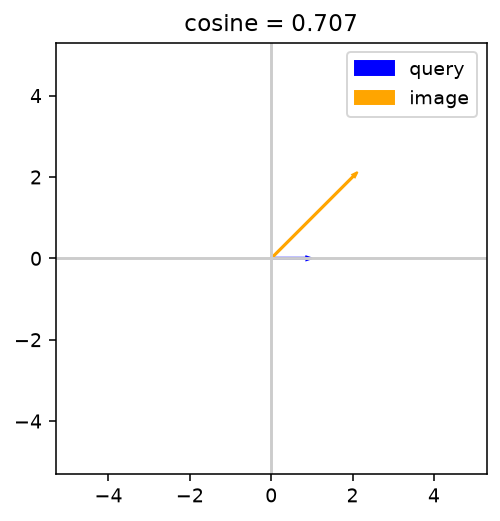

In [ ]:
panel('geometry',{'angle':W.IntSlider(value=45,min=0,max=180,description='Угол θ'),'norm':W.FloatSlider(value=3,min=.1,max=5,description='Норма'),'normalize':W.Checkbox(value=True,description='cosine')},geometry)

## Стенд 2 · Контрастивная задача и температура (учебная матрица)

Строки — три изображения, столбцы — три текста. Положительные пары заданы индексами. Цель CLIP — среднее CE
в направлениях image→text и text→image. Используется $P_{ij}=\exp(s_{ij}/\tau)/\sum_k\exp(s_{ik}/\tau)$.
Матрица придумана для объяснения; ниже **не обучается CLIP**.

1. При правильных парах уменьшите τ: предскажите изменение loss и максимальной доли softmax.
2. Сделайте negative=.9: сильный негатив лучше истинной пары .8. Повторите τ=.03 и объясните штраф.
3. Включите неверные пары. Почему уверенность в исходных совпадениях больше не помогает функции потерь?
4. Сравните симметричную CE с одним направлением на бумаге. Почему обратные target должны быть обратной перестановкой?

Статический проверенный учебный пример: τ=.15, hard negative=.2, правильные пары; symmetric CE≈.0388. Матрица синтетическая, не outputs CLIP.

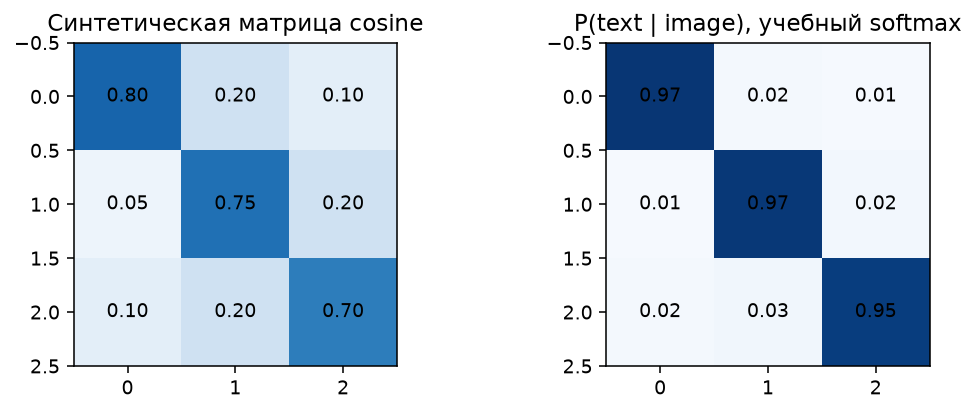

In [ ]:
panel('contrastive',{'tau':W.FloatSlider(value=.15,min=.02,max=1,step=.02,description='τ'),'hard_negative':W.FloatSlider(value=.2,min=0,max=.95,step=.05,description='negative'),'wrong_pair':W.Checkbox(value=False,description='Неверные пары')},contrastive)

## Реальная галерея и CLIP

Восемь общедоступных изображений scikit-image: семь фотографических изображений и CC0 силуэт лошади.
Права и авторы перечислены в `DATA_MANIFEST` и README. Это маленький диагностический набор, а не оценка generalization.
Модель: OpenAI CLIP ViT-B/32, frozen, английские запросы. Размер/нормализация берутся из её процессора.
При первом запуске загружаются фиксированные официальные веса. Сетевые ошибки не заменяются фиктивными признаками.

In [ ]:
images=gallery()
clip=FrozenCLIP()
image_features=clip.images(images)
print('Реальное кодирование 8 изображений:',round(clip.last_seconds,3),'s')
_gallery_figure=show_gallery(images,title='Галерея: 7 фотографических изображений и силуэт horse')

## Стенд 3 · Реальный поиск: формулировка, top-k, crop

Текст и фото кодируются один раз для каждого опыта; сортируем по cosine. Ползунок crop задаёт центральную долю
каждой картинки **до стандартного preprocessing CLIP**. На панели показаны исходники для узнаваемости.

1. Сравните `a cat`, `a cup of coffee`, `a rocket launch`. До запуска назовите ожидаемый top-1.
2. Введите `a red fire truck`: объекта в галерее нет. Почему top-1 всё равно существует?
3. Для одного запроса поменяйте crop 1.0 → 0.5 → 0.2. Запишите top-1 score и margin, объясните потерю контекста.
4. Проверьте `a black and white drawing of a horse`. Сравните рисованный объект с фотографиями: это уже сдвиг домена.
5. Запишите собственную двусмысленную формулировку, ожидаемые relevant IDs и случай расхождения с моделью.

In [ ]:
panel('retrieval',{'query':W.Text(value='a cat',description='Текст'),'crop':W.FloatSlider(value=1,min=.2,max=1,step=.1,description='Crop'),'k':W.IntSlider(value=4,min=1,max=8,description='top-k')},retrieval,button=True)

## Стенд 4 · Словарь меняет softmax, но не cosine (реальные признаки)

При фиксированной фотографии chelsea нормированные признаки пары неизменны. Добавление похожего текста меняет
знаменатель softmax. Показанная температура учебная: мы намеренно не выдаём эти числа за откалиброванную вероятность.

1. Добавьте `a kitten` и проследите cosine пары photo–`a cat` и её долю softmax.
2. Уберите правильный класс. Какой ответ становится уверенным при маленькой τ? Почему это не проверка наличия объекта?
3. Сравните τ=.04 и .5, запишите изменение top-1 и максимальной доли. Может ли τ менять порядок фиксированных scores?

In [ ]:
vocabularies={'базовый':['a cat','a dog','a cup'],'с дубликатом смысла':['a cat','a kitten','a dog','a cup'],'без правильного класса':['a dog','a cup','a rocket']}
vocab_embeddings={k:clip.texts(v) for k,v in vocabularies.items()}
panel('vocabulary',{'variant':W.Dropdown(options=list(vocabularies),description='Словарь'),'tau':W.FloatSlider(value=.1,min=.02,max=1,step=.02,description='τ')},vocabulary)

## Стенд 5 · Hit@k, Recall@k, AP — разные вопросы (учебное ранжирование)

Порядок A,B,C,D,E уже зафиксирован. Вы управляете разметкой и k. Precision@k — доля relevant среди показанных;
Recall@k — доля найденных от всех relevant; Hit@k — нашёлся хотя бы один. AP усредняет precision на позициях relevant,
деля на их общее число; MRR использует только первый relevant. Recall при отсутствии relevant математически не определён; реализация возвращает 0 по техническому соглашению для прямоугольных массивов. Положительный retrieval оцениваем только по запросам с GT; absent-запросы — отдельной метрикой отказа.

1. Начальное состояние A,C,E relevant: k=1 даёт Hit=1, Recall=1/3. Объясните расхождение.
2. Перенесите первый relevant с A на B. Что изменится у MRR и AP?
3. Два аннотатора разошлись насчёт B: покажите, что метрика меняется без изменения алгоритма.
4. Сопоставьте с реальной галереей: `a person` может иметь несколько relevant. Нельзя автоматически считать только один верным.

In [ ]:
panel('ranking',{'k':W.IntSlider(value=3,min=1,max=5,description='k'),'first':W.Checkbox(value=True,description='A релевантен'),'second':W.Checkbox(value=False,description='B релевантен'),'third':W.Checkbox(value=True,description='C релевантен')},ranking)

## Стенд 6 · Текст → рамки (реальные Grounding DINO и Penn–Fudan)

CLIP выдаёт глобальную оценку изображения. Grounding DINO выдаёт рамки и согласование с токенами.
Box threshold оставляет запросы по максимальной token score; text threshold определяет токены фразы в подписи.
Это разные операции. Penn–Fudan содержит GT людей; отдельные `red jacket` не размечены. Поэтому здесь оцениваем `a person.`.

1. Измените box threshold .1 → .3 → .7. Запишите число рамок, score и IoU. Пустой результат допустим.
2. Зафиксируйте box threshold и меняйте text threshold: что стало с рамками и подписью?
3. Попробуйте `a pedestrian.`. Новая формулировка запускает модель; изменение только порогов повторно использует logits.
4. Укажите пропуск и/или дубликат. Почему числа рамок недостаточно для оценки детекции?

Зелёный — результат модели, пурпурный пунктир — GT. На Penn–Fudan не делаем выводов о zero-shot переносе:
этот маленький набор используется для диагностики конвейера, а `person` — распространённая категория.

In [ ]:
panel('grounding',{'box_threshold':W.FloatSlider(value=.3,min=.05,max=.95,step=.05,description='box thr'),'text_threshold':W.FloatSlider(value=.25,min=.05,max=.95,step=.05,description='text thr'),'prompt':W.Text(value='a person.',description='Текст')},grounding,button=True)

## Стенд 7 · Рамка → маска: отделяем ошибку подсказки от SAM

Берём первую **истинную** рамку (oracle-подсказку), затем сдвигаем и масштабируем. Это диагностический опыт,
а не конечный автоматический pipeline: рамка GT недоступна при обычном инференсе. SAM не получает текст.
Его predicted quality — оценка модели; mask IoU ниже рассчитан отдельно по GT пикселям.

1. Измерьте исходный box IoU и mask IoU. Почему даже при box IoU=1 маска может ошибаться?
2. Измените dx 0 → 30 и масштаб 1 → .8 по одному. Сравните box IoU, mask IoU и predicted quality.
3. Найдите опыт, в котором большая рамка даёт более точную маску, чем сдвинутая. Какие части человека потеряны?
4. Перейдите к самостоятельной части: оцените полный DINO→SAM, штрафуя пропущенный GT нулём.

In [ ]:
panel('segmentation',{'shift_x':W.IntSlider(value=0,min=-40,max=40,description='dx px'),'scale':W.FloatSlider(value=1,min=.6,max=1.4,step=.1,description='Масштаб')},segmentation,button=True)

## Протокол наблюдений и переход к самостоятельной работе

Сохраните 2–3 опыта на стенд, включая трудный случай; не достаточно скриншота исходного состояния.
Для трёх опытов приведите исходный прогноз, который оказался неверным или неполным.
Далее `02_retrieval_and_grounding.ipynb`: реализуйте метрики/прототипы/отказ/сопоставление и проведите общий эксперимент.
Автономные исследовательские продолжения находятся в `03_optional_experiments.ipynb`.

**Источники:** [CLIP](https://proceedings.mlr.press/v139/radford21a.html),
[Grounding DINO](https://arxiv.org/abs/2303.05499), [SAM](https://openaccess.thecvf.com/content/ICCV2023/html/Kirillov_Segment_Anything_ICCV_2023_paper.html),
[Penn–Fudan](https://www.cis.upenn.edu/~jshi/ped_html/), [scikit-image data](https://scikit-image.org/docs/0.25.x/api/skimage.data.html).